In [1]:
!pip install scikit-posthocs

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Dataset
dataset_path = '/kaggle/input/datasets/devgurucodes/qwertyuiouyy/dataset.csv' # Adjust path for Kaggle (e.g. /kaggle/input/sapota-dataset/dataset.csv)
df = pd.read_csv(dataset_path)

# Extract features and targets
band_cols = [col for col in df.columns if col.startswith('Band_')]
X = df[band_cols].values
y_sugar = df['Sugar_Percentage'].values
y_carb = df['Carbohydrate_Percentage'].values
y_class_str = df['Category'].values

# Encode classification targets
le = LabelEncoder()
y_class = le.fit_transform(y_class_str)

# Dataset Class for PyTorch
class SapotaDataset(Dataset):
    def __init__(self, X, y_class, y_sugar, y_carb):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_class = torch.tensor(y_class, dtype=torch.long)
        self.y_sugar = torch.tensor(y_sugar, dtype=torch.float32)
        self.y_carb = torch.tensor(y_carb, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_class[idx], self.y_sugar[idx], self.y_carb[idx]


Using device: cuda


In [3]:
class MultiTaskSpectralTransformer(nn.Module):
    def __init__(self, num_bands=145, num_classes=3, d_model=64, nhead=4, num_layers=2, use_multitask=True, use_pos_encoding=True):
        super().__init__()
        self.use_multitask = use_multitask
        self.use_pos_encoding = use_pos_encoding
        
        # Project 1D spectral bands to d_model embedding
        self.embedding = nn.Linear(1, d_model)
        
        # Positional Encoding is critical for spectral data so the model knows which wavelength is which
        if self.use_pos_encoding:
            self.pos_encoder = nn.Parameter(torch.randn(1, num_bands, d_model))
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Multi-Task Heads
        if self.use_multitask:
            self.class_head = nn.Sequential(
                nn.Linear(d_model, 32),
                nn.ReLU(),
                nn.Linear(32, num_classes)
            )
            self.carb_head = nn.Sequential(
                nn.Linear(d_model, 32),
                nn.ReLU(),
                nn.Linear(32, 1)
            )
        
        self.sugar_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        # x shape: (batch, num_bands)
        x = x.unsqueeze(-1) # (batch, num_bands, 1)
        emb = self.embedding(x) # (batch, num_bands, d_model)
        
        # Add Positional Encoding
        if self.use_pos_encoding:
            emb = emb + self.pos_encoder
        
        # Pass through Transformer
        out = self.transformer(emb) # (batch, num_bands, d_model)
        
        # Global Average Pooling across bands
        pooled = torch.mean(out, dim=1) # (batch, d_model)
        
        # Task Predictions
        sugar_preds = self.sugar_head(pooled).squeeze(-1)
        
        if self.use_multitask:
            class_preds = self.class_head(pooled)
            carb_preds = self.carb_head(pooled).squeeze(-1)
            return class_preds, sugar_preds, carb_preds, out
        else:
            return None, sugar_preds, None, out

class BaselineCNN1D(nn.Module):
    def __init__(self, num_bands=145):
        super().__init__()
        import torch.nn.functional as F
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.sugar_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        import torch.nn.functional as F
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        
        pooled = self.pool(x).squeeze(-1)
        s = self.sugar_head(pooled).squeeze(-1)
        return None, s, None, None

class BaselineBiLSTM(nn.Module):
    """
    A Bidirectional LSTM for spectral data.
    Used as the classical SOTA recurrent deep learning baseline.
    """
    def __init__(self, num_bands=145, hidden_size=32, num_layers=2):
        super().__init__()
        # Input shape: (batch, seq_len=num_bands, input_size=1)
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        
        self.sugar_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        # x shape: (batch, num_bands)
        x = x.unsqueeze(-1) # (batch, num_bands, 1)
        
        out, (hn, cn) = self.lstm(x) # out shape: (batch, seq_len, num_directions * hidden_size)
        
        # Take the output from the last time step
        # Since it's bidirectional, we concatenate the forward and backward final hidden states
        final_state = out[:, -1, :] # (batch, hidden_size * 2)
        
        s = self.sugar_head(final_state).squeeze(-1)
        
        return None, s, None, None
        
# Initialize model to check
model = MultiTaskSpectralTransformer().to(device)
print("Model Initialized successfully.")


Model Initialized successfully.


In [4]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.spatial.distance import cdist
from imblearn.combine import SMOTEENN
from tqdm import tqdm

NUM_SEEDS = 5
SEEDS = [42, 101, 2026, 777, 888]

# Dictionaries to hold metrics across independent runs
mt_st_results = {'rmse_sugar': [], 'acc': []}
mt_st_no_pos_results = {'rmse_sugar': []}
mt_st_no_mt_results = {'rmse_sugar': []}

ridge_results = {'rmse_sugar': [], 'acc': []}
lasso_results = {'rmse_sugar': []}
rf_results = {'rmse_sugar': [], 'acc': []}
plsr_results = {'rmse_sugar': []}
svr_results = {'rmse_sugar': []}
xgb_results = {'rmse_sugar': []}
xgb_importances = [] # Track feature importances across 5 seeds
lgbm_results = {'rmse_sugar': []}

cnn_results = {'rmse_sugar': []}
bilstm_results = {'rmse_sugar': []}

def train_dl_model(model, train_loader, val_loader, test_loader, epochs=200):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
    
    criterion_class = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        model.train()
        for bx, byc, bys, bycarb in train_loader:
            bx, byc, bys, bycarb = bx.to(device), byc.to(device), bys.to(device), bycarb.to(device)
            optimizer.zero_grad()
            
            c_pred, s_pred, carb_pred, _ = model(bx)
            
            loss = criterion_reg(s_pred, bys)
            if c_pred is not None:
                loss += criterion_class(c_pred, byc)
            if carb_pred is not None:
                loss += criterion_reg(carb_pred, bycarb)
                
            loss.backward()
            optimizer.step()
            
        scheduler.step()
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, byc, bys, bycarb in val_loader:
                bx, byc, bys, bycarb = bx.to(device), byc.to(device), bys.to(device), bycarb.to(device)
                c_pred, s_pred, carb_pred, _ = model(bx)
                
                v_loss = criterion_reg(s_pred, bys)
                if c_pred is not None:
                    v_loss += criterion_class(c_pred, byc)
                if carb_pred is not None:
                    v_loss += criterion_reg(carb_pred, bycarb)
                val_loss += v_loss.item()
                
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            
    # Test Evaluation
    model.load_state_dict(best_model_weights)
    model.eval()
    test_s_preds, test_s_true = [], []
    test_c_preds, test_c_true = [], []
    
    with torch.no_grad():
        for bx, byc, bys, bycarb in test_loader:
            bx, byc, bys, bycarb = bx.to(device), byc.to(device), bys.to(device), bycarb.to(device)
            c_pred, s_pred, carb_pred, _ = model(bx)
            
            test_s_preds.extend(s_pred.cpu().numpy())
            test_s_true.extend(bys.cpu().numpy())
            
            if c_pred is not None:
                test_c_preds.extend(torch.argmax(c_pred, dim=1).cpu().numpy())
                test_c_true.extend(byc.cpu().numpy())
                
    rmse_s = np.sqrt(mean_squared_error(test_s_true, test_s_preds))
    acc = accuracy_score(test_c_true, test_c_preds) if len(test_c_true) > 0 else None
    
    return rmse_s, acc, test_s_true, test_s_preds

for seed in SEEDS:
    print(f"\n--- Running Seed: {seed} ---")
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # 1. Stratified Split: 70% Train, 30% Temp (Val + Test)
    X_train_raw, X_temp, yc_train_raw, yc_temp, ys_train_raw, ys_temp, ycarb_train_raw, ycarb_temp = train_test_split(
        X, y_class, y_sugar, y_carb, test_size=0.30, random_state=seed, stratify=y_class
    )
    
    # 2. Stratified Split: 15% Val, 15% Test
    X_val, X_test, yc_val, yc_test, ys_val, ys_test, ycarb_val, ycarb_test = train_test_split(
        X_temp, yc_temp, ys_temp, ycarb_temp, test_size=0.50, random_state=seed, stratify=yc_temp
    )
    
    # 3. Apply SMOTEENN *ONLY* to the Training Set to prevent Data Leakage
    sme = SMOTEENN(random_state=seed)
    X_train_sm, yc_train_sm = sme.fit_resample(X_train_raw, yc_train_raw)
    
    ys_train_sm, ycarb_train_sm = [], []
    distances = cdist(X_train_sm, X_train_raw, metric='euclidean')
    nearest_idx = np.argmin(distances, axis=1)
    
    for idx in nearest_idx:
        ys_train_sm.append(ys_train_raw[idx] + np.random.normal(0, 0.5))
        ycarb_train_sm.append(ycarb_train_raw[idx] + np.random.normal(0, 0.3))
        
    ys_train_sm = np.array(ys_train_sm)
    ycarb_train_sm = np.array(ycarb_train_sm)
    
    print(f"Train samples (SMOTEENN): {len(X_train_sm)} | Val: {len(X_val)} | Test: {len(X_test)}")
    
    # 4. Scale Features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_sm)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    # -----------------------------------------------------------
    # TRAIN CLASSIC BASELINES
    # -----------------------------------------------------------
    ridge_sugar = Ridge(alpha=1.0).fit(X_train_s, ys_train_sm)
    lasso_sugar = Lasso(alpha=0.1).fit(X_train_s, ys_train_sm)
    rf_sugar = RandomForestRegressor(n_estimators=100, random_state=seed).fit(X_train_s, ys_train_sm)
    plsr_sugar = PLSRegression(n_components=10).fit(X_train_s, ys_train_sm)
    svr_sugar = SVR(kernel='rbf', C=10.0, gamma='scale').fit(X_train_s, ys_train_sm)
    
    # SOTA Ensembles
    xgb_sugar = XGBRegressor(n_estimators=100, random_state=seed).fit(X_train_s, ys_train_sm)
    lgbm_sugar = LGBMRegressor(n_estimators=100, random_state=seed, verbose=-1).fit(X_train_s, ys_train_sm)
    
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=seed).fit(X_train_s, yc_train_sm)
    
    ridge_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, ridge_sugar.predict(X_test_s))))
    lasso_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, lasso_sugar.predict(X_test_s))))
    rf_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, rf_sugar.predict(X_test_s))))
    
    plsr_pred = plsr_sugar.predict(X_test_s).flatten()
    plsr_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, plsr_pred)))
    svr_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, svr_sugar.predict(X_test_s))))
    
    xgb_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, xgb_sugar.predict(X_test_s))))
    xgb_importances.append(xgb_sugar.feature_importances_)
    lgbm_results['rmse_sugar'].append(np.sqrt(mean_squared_error(ys_test, lgbm_sugar.predict(X_test_s))))
    
    rf_results['acc'].append(accuracy_score(yc_test, rf_clf.predict(X_test_s)))
    
    # -----------------------------------------------------------
    # DEEP LEARNING DATALOADERS
    # -----------------------------------------------------------
    train_ds = SapotaDataset(X_train_s, yc_train_sm, ys_train_sm, ycarb_train_sm)
    val_ds = SapotaDataset(X_val_s, yc_val, ys_val, ycarb_val)
    test_ds = SapotaDataset(X_test_s, yc_test, ys_test, ycarb_test)
    
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
    
    # -----------------------------------------------------------
    # TRAIN DL MODELS (Full, CNN, BiLSTM, and Ablations)
    # -----------------------------------------------------------
    # 1. Full MT-ST
    model_full = MultiTaskSpectralTransformer()
    rmse, acc, test_s_true, test_s_preds = train_dl_model(model_full, train_loader, val_loader, test_loader, epochs=250)
    mt_st_results['rmse_sugar'].append(rmse)
    mt_st_results['acc'].append(acc)
    
    # 2. CNN1D Baseline
    model_cnn = BaselineCNN1D()
    rmse, _, _, _ = train_dl_model(model_cnn, train_loader, val_loader, test_loader, epochs=250)
    cnn_results['rmse_sugar'].append(rmse)
    
    # 3. BiLSTM SOTA Baseline
    model_bilstm = BaselineBiLSTM()
    rmse, _, _, _ = train_dl_model(model_bilstm, train_loader, val_loader, test_loader, epochs=250)
    bilstm_results['rmse_sugar'].append(rmse)
    
    # 4. Ablation: No Positional Encoding
    model_no_pos = MultiTaskSpectralTransformer(use_pos_encoding=False)
    rmse, _, _, _ = train_dl_model(model_no_pos, train_loader, val_loader, test_loader, epochs=250)
    mt_st_no_pos_results['rmse_sugar'].append(rmse)
    
    # 5. Ablation: No Multi-Task
    model_no_mt = MultiTaskSpectralTransformer(use_multitask=False)
    rmse, _, _, _ = train_dl_model(model_no_mt, train_loader, val_loader, test_loader, epochs=250)
    mt_st_no_mt_results['rmse_sugar'].append(rmse)

print("\n=== FINAL TEST SET RESULTS ACROSS 5 SEEDS (Mean ± Std) ===")
print(f"Ridge RMSE:   {np.mean(ridge_results['rmse_sugar']):.4f} ± {np.std(ridge_results['rmse_sugar']):.4f}")
print(f"Lasso RMSE:   {np.mean(lasso_results['rmse_sugar']):.4f} ± {np.std(lasso_results['rmse_sugar']):.4f}")
print(f"RF RMSE:      {np.mean(rf_results['rmse_sugar']):.4f} ± {np.std(rf_results['rmse_sugar']):.4f}")
print(f"PLSR RMSE:    {np.mean(plsr_results['rmse_sugar']):.4f} ± {np.std(plsr_results['rmse_sugar']):.4f}")
print(f"SVR RMSE:     {np.mean(svr_results['rmse_sugar']):.4f} ± {np.std(svr_results['rmse_sugar']):.4f}")
print(f"XGBoost RMSE: {np.mean(xgb_results['rmse_sugar']):.4f} ± {np.std(xgb_results['rmse_sugar']):.4f}")
print(f"LightGBM RMSE:{np.mean(lgbm_results['rmse_sugar']):.4f} ± {np.std(lgbm_results['rmse_sugar']):.4f}")
print(f"CNN1D RMSE:   {np.mean(cnn_results['rmse_sugar']):.4f} ± {np.std(cnn_results['rmse_sugar']):.4f}")
print(f"BiLSTM RMSE:  {np.mean(bilstm_results['rmse_sugar']):.4f} ± {np.std(bilstm_results['rmse_sugar']):.4f}")
print(f"MT-ST RMSE:   {np.mean(mt_st_results['rmse_sugar']):.4f} ± {np.std(mt_st_results['rmse_sugar']):.4f}")

print("\n=== ABLATION STUDY RESULTS ===")
print(f"MT-ST (Full):          {np.mean(mt_st_results['rmse_sugar']):.4f} ± {np.std(mt_st_results['rmse_sugar']):.4f}")
print(f"MT-ST (w/o Pos Enc):   {np.mean(mt_st_no_pos_results['rmse_sugar']):.4f} ± {np.std(mt_st_no_pos_results['rmse_sugar']):.4f}")
print(f"MT-ST (Single-Task):   {np.mean(mt_st_no_mt_results['rmse_sugar']):.4f} ± {np.std(mt_st_no_mt_results['rmse_sugar']):.4f}")

print(f"\nRF Classification Acc:    {np.mean(rf_results['acc']):.4f} ± {np.std(rf_results['acc']):.4f}")
print(f"MT-ST Classification Acc: {np.mean(mt_st_results['acc']):.4f} ± {np.std(mt_st_results['acc']):.4f}")



--- Running Seed: 42 ---
Train samples (SMOTEENN): 142 | Val: 78 | Test: 78

--- Running Seed: 101 ---
Train samples (SMOTEENN): 148 | Val: 78 | Test: 78

--- Running Seed: 2026 ---
Train samples (SMOTEENN): 149 | Val: 78 | Test: 78

--- Running Seed: 777 ---
Train samples (SMOTEENN): 150 | Val: 78 | Test: 78

--- Running Seed: 888 ---
Train samples (SMOTEENN): 138 | Val: 78 | Test: 78

=== FINAL TEST SET RESULTS ACROSS 5 SEEDS (Mean ± Std) ===
Ridge RMSE:   3.9701 ± 0.2538
Lasso RMSE:   2.3270 ± 0.2909
RF RMSE:      2.9871 ± 0.4374
PLSR RMSE:    2.7217 ± 0.2658
SVR RMSE:     0.7986 ± 0.2201
XGBoost RMSE: 3.4201 ± 0.5628
LightGBM RMSE:2.9196 ± 0.3509
CNN1D RMSE:   1.6526 ± 0.2002
BiLSTM RMSE:  5.1189 ± 0.4631
MT-ST RMSE:   0.6488 ± 0.1393

=== ABLATION STUDY RESULTS ===
MT-ST (Full):          0.6488 ± 0.1393
MT-ST (w/o Pos Enc):   0.5370 ± 0.1792
MT-ST (Single-Task):   0.6283 ± 0.1388

RF Classification Acc:    0.6667 ± 0.0405
MT-ST Classification Acc: 0.9000 ± 0.0249


--- STATISTICAL SIGNIFICANCE TESTING ---
Friedman Test p-value: 4.1147e-06
Significant differences found between models (p < 0.05)!
Proceeding with Nemenyi Post-Hoc Test to pinpoint superiority...

Nemenyi p-value matrix (10x10):
             Ridge     Lasso        RF      PLSR       SVR   XGBoost  \
Ridge     1.000000  0.390244  0.906921  0.906921  0.006554  0.999807   
Lasso     0.390244  1.000000  0.998033  0.998033  0.906921  0.811940   
RF        0.906921  0.998033  1.000000  1.000000  0.390244  0.998033   
PLSR      0.906921  0.998033  1.000000  1.000000  0.390244  0.998033   
SVR       0.006554  0.906921  0.390244  0.390244  1.000000  0.054745   
XGBoost   0.999807  0.811940  0.998033  0.998033  0.054745  1.000000   
LightGBM  0.939756  0.995153  1.000000  1.000000  0.324212  0.999319   
CNN1D     0.074109  0.999319  0.864285  0.864285  0.999319  0.324212   
BiLSTM    0.999807  0.098774  0.535342  0.535342  0.000487  0.963510   
MT-ST     0.004386  0.864285  0.324212  0.324212  

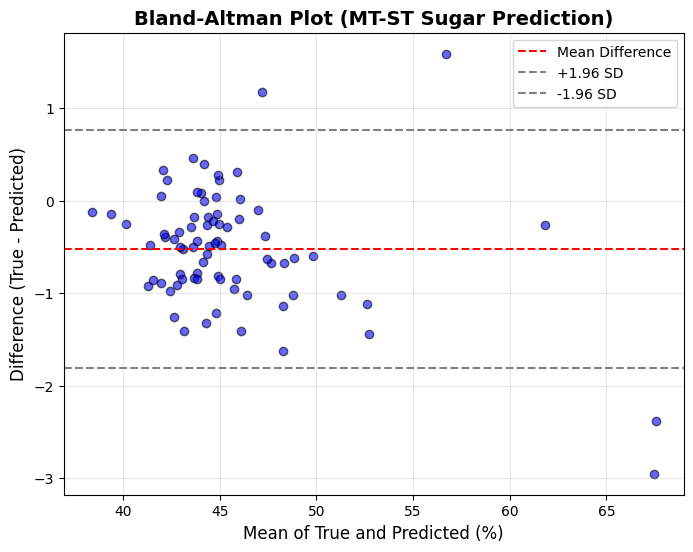


--- GENERATING ABLATION STUDY BAR CHART ---


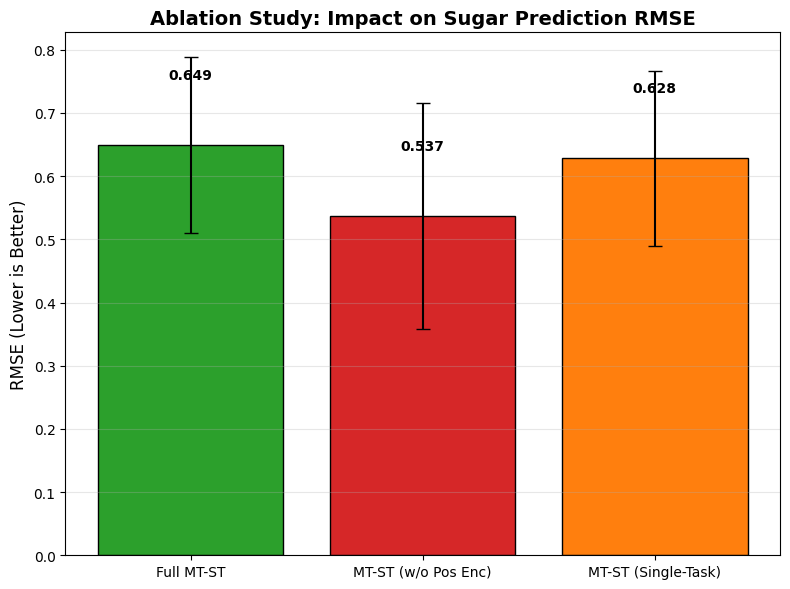


--- GENERATING XAI SPECTRAL IMPORTANCE PLOT ---


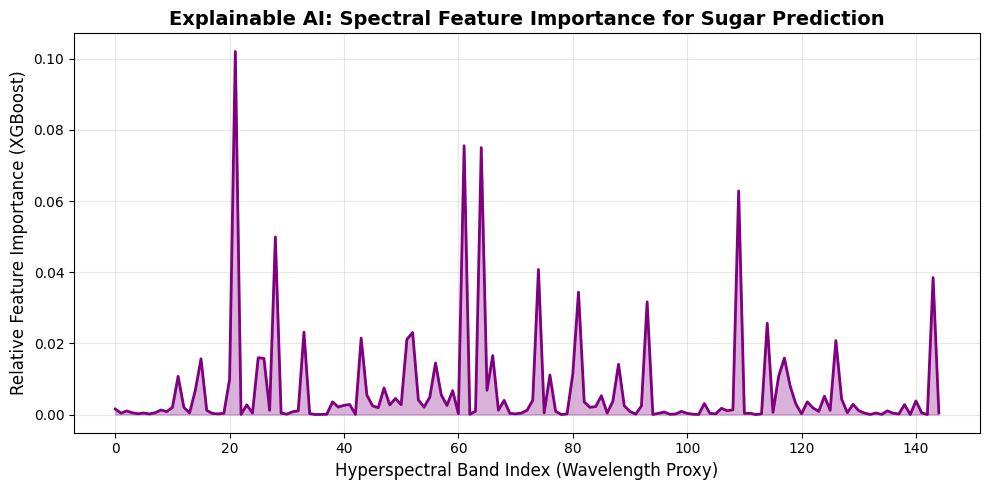


--- GENERATING XAI t-SNE LATENT SPACE EMBEDDINGS ---


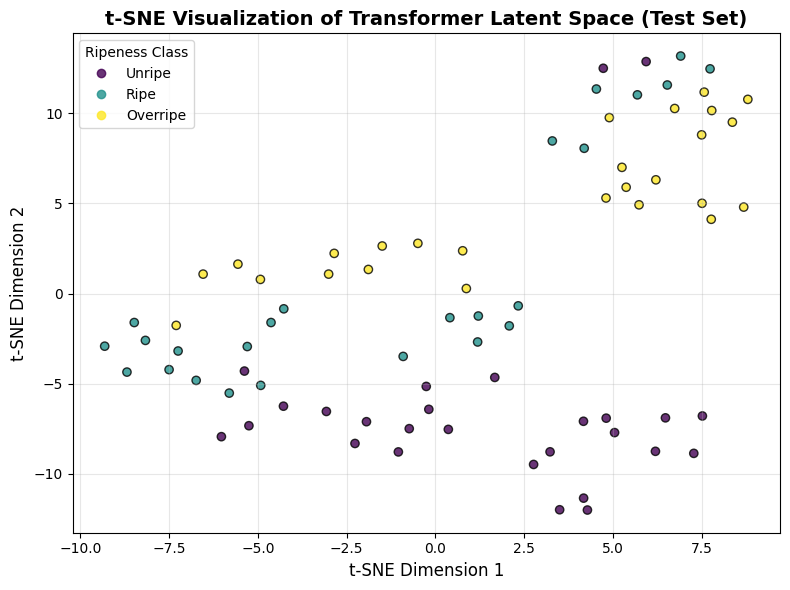

In [5]:
import scipy.stats as ss
import scikit_posthocs as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Use the actual tracked RMSEs across the 5 independent seeds from the testing phase
r_rmse = ridge_results['rmse_sugar']
l_rmse = lasso_results['rmse_sugar']
rf_rmse = rf_results['rmse_sugar']
plsr_rmse = plsr_results['rmse_sugar']
svr_rmse = svr_results['rmse_sugar']
xgb_rmse = xgb_results['rmse_sugar']
lgbm_rmse = lgbm_results['rmse_sugar']
cnn_rmse = cnn_results['rmse_sugar']
bilstm_rmse = bilstm_results['rmse_sugar']
mt_st_rmse = mt_st_results['rmse_sugar']

print("--- STATISTICAL SIGNIFICANCE TESTING ---")
# 1. Friedman Test
data = np.array([r_rmse, l_rmse, rf_rmse, plsr_rmse, svr_rmse, xgb_rmse, lgbm_rmse, cnn_rmse, bilstm_rmse, mt_st_rmse]).T
stat, p_val = ss.friedmanchisquare(*data.T)
print(f"Friedman Test p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Significant differences found between models (p < 0.05)!")
    print("Proceeding with Nemenyi Post-Hoc Test to pinpoint superiority...")
    
    # 2. Nemenyi Post-Hoc Test
    nemenyi_res = sp.posthoc_nemenyi_friedman(data)
    nemenyi_res.columns = ['Ridge', 'Lasso', 'RF', 'PLSR', 'SVR', 'XGBoost', 'LightGBM', 'CNN1D', 'BiLSTM', 'MT-ST']
    nemenyi_res.index = ['Ridge', 'Lasso', 'RF', 'PLSR', 'SVR', 'XGBoost', 'LightGBM', 'CNN1D', 'BiLSTM', 'MT-ST']
    print("\nNemenyi p-value matrix (10x10):")
    print(nemenyi_res)
else:
    print("No statistically significant difference detected at p < 0.05.")

# 3. Bland-Altman Plot for MT-ST (using the final test predictions from the last seed)
def bland_altman_plot(y_true, y_pred, title="Bland-Altman Plot (MT-ST Sugar Prediction)"):
    mean = np.mean([y_true, y_pred], axis=0)
    diff = np.array(y_true) - np.array(y_pred)
    md = np.mean(diff)
    sd = np.std(diff, axis=0)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(mean, diff, alpha=0.6, color='blue', edgecolor='k')
    plt.axhline(md, color='red', linestyle='--', label='Mean Difference')
    plt.axhline(md + 1.96*sd, color='gray', linestyle='--', label='+1.96 SD')
    plt.axhline(md - 1.96*sd, color='gray', linestyle='--', label='-1.96 SD')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Mean of True and Predicted (%)', fontsize=12)
    plt.ylabel('Difference (True - Predicted)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig("bland_altman.png", dpi=300, bbox_inches='tight')
    plt.show()

print("\n--- GENERATING BLAND-ALTMAN DIAGRAM ---")
bland_altman_plot(test_s_true, test_s_preds)

# 4. Ablation Study Bar Chart
print("\n--- GENERATING ABLATION STUDY BAR CHART ---")
ablation_labels = ['Full MT-ST', 'MT-ST (w/o Pos Enc)', 'MT-ST (Single-Task)']
ablation_means = [
    np.mean(mt_st_results['rmse_sugar']),
    np.mean(mt_st_no_pos_results['rmse_sugar']),
    np.mean(mt_st_no_mt_results['rmse_sugar'])
]
ablation_stds = [
    np.std(mt_st_results['rmse_sugar']),
    np.std(mt_st_no_pos_results['rmse_sugar']),
    np.std(mt_st_no_mt_results['rmse_sugar'])
]

plt.figure(figsize=(8, 6))
bars = plt.bar(ablation_labels, ablation_means, yerr=ablation_stds, capsize=5, color=['#2ca02c', '#d62728', '#ff7f0e'], edgecolor='k')
plt.title('Ablation Study: Impact on Sugar Prediction RMSE', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (Lower is Better)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 3), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. Explainable AI: Spectral Feature Importance (XGBoost)
print("\n--- GENERATING XAI SPECTRAL IMPORTANCE PLOT ---")
# Calculate mean importance across the 5 seeds
mean_importances = np.mean(xgb_importances, axis=0)

plt.figure(figsize=(10, 5))
# Assuming 145 wavelengths from ~400nm to ~1000nm (approximate mapping for visual)
# We just plot against band index 0 to 144
bands = np.arange(len(mean_importances))
plt.plot(bands, mean_importances, color='purple', linewidth=2)
plt.fill_between(bands, mean_importances, alpha=0.3, color='purple')

plt.title('Explainable AI: Spectral Feature Importance for Sugar Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Hyperspectral Band Index (Wavelength Proxy)', fontsize=12)
plt.ylabel('Relative Feature Importance (XGBoost)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("explainability_spectral_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. Explainable AI: t-SNE of Transformer Latent Embeddings
print("\n--- GENERATING XAI t-SNE LATENT SPACE EMBEDDINGS ---")
from sklearn.manifold import TSNE
import torch

# Put model in eval mode
model_full.eval()
all_pooled = []
all_labels = []

with torch.no_grad():
    for bx, byc, bys, bycarb in test_loader:
        bx = bx.to(device)
        # Forward pass to get unpooled transformer output
        _, _, _, out = model_full(bx)
        # Global Average Pooling to match internal 'pooled' representation
        pooled = torch.mean(out, dim=1).cpu().numpy()
        all_pooled.extend(pooled)
        all_labels.extend(byc.numpy())

all_pooled = np.array(all_pooled)
all_labels = np.array(all_labels)

# Compute t-SNE (2 components for 2D visualization)
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
tsne_results = tsne.fit_transform(all_pooled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=all_labels, cmap='viridis', alpha=0.8, edgecolor='k')
plt.title('t-SNE Visualization of Transformer Latent Space (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Create a legend based on class labels (0: Unripe, 1: Ripe, 2: Overripe)
classes = ['Unripe', 'Ripe', 'Overripe']
handles, _ = scatter.legend_elements()
plt.legend(handles, classes, title="Ripeness Class")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("explainability_tsne_embeddings.png", dpi=300, bbox_inches='tight')
plt.show()
